# Chương 4. HỌC MÁY

### Thuật toán DBSCAN
Tương tự như K-Means, DBSCAN không tốn thời gian cho việc huấn luyện cũng như sử dụng các giải thuật tối ưu để xác định cực trị cho hàm mất mát như các mô hình học giám sát khác. Chi tiết để xây dựng DBSCAN được mô tả như sau:

- Bước 1: Khởi tạo tham số  $\epsilon$ và minPts.
- Bước 2: Chọn ngẫu nhiên một điểm bắt đầu và đánh dấu điểm đã xử lý (visited point).
- Bước 3: Xác định tất cả điểm lận cận từ bán kính  $\epsilon$ đã chọn khi đó ta có các trường hợp: 
    - Nếu số điểm lân cận xác định được trong bán kính $\epsilon$ lớn hơn hoặc bằng minPts ta gọi điểm đó là điểm trung tâm và hình thành cụm.
    - Trong các điểm lân cận của điểm trung tâm (core point), điểm có số lân cận trong bán kính $\epsilon$ ít hơn minPts và chứa ít nhất một điểm trung tâm được gọi là điểm biên (border point).
    - Nếu số điểm lân cận xác định ít hơn minPts ta gọi điểm đó là điểm nhiễu (noise point).
- Bước 4: Tất cả điểm lân cận của điểm trung tâm cũng được thêm vào cụm theo nguyên tắc đệ quy, ngoài ra các điểm biên cũng được thêm vào cụm.
- Bước 5: Lặp lại toàn bộ các điểm khác có trong dữ liệu chưa xử lý từ bước 3 đến bước 4 và điểm ban đầu được gán là nhiễu có thể trở thành điểm biên nếu chúng nằm trong khoảng cách  $\epsilon$ của một điểm trung tâm khác.
- Bước 6: Hoàn tất quá trình phân cụm và các điểm không thuộc vào bất kỳ cụm nào sẽ được xem là điểm nhiễu.

<p align="center">
  <img src="../picture/DBSCAN.drawio.png" width="600">
  <br>
  <em>Hình 1. Các bước xây dựng DBSCAN.</em>
</p>

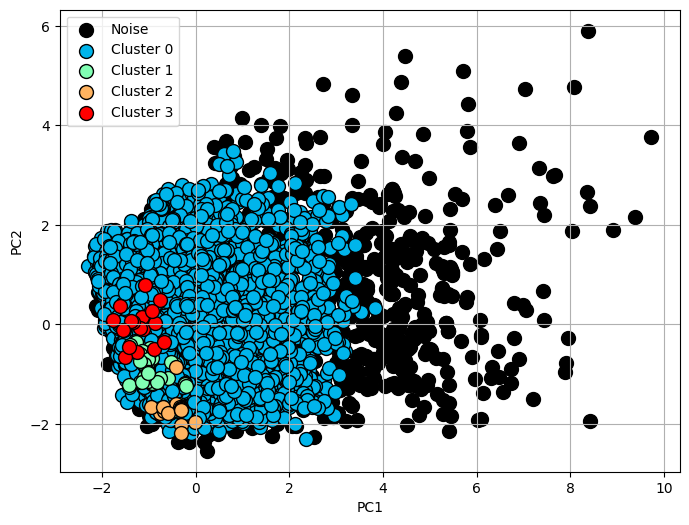

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Đọc dữ liệu
cus = pd.read_csv('../data/customer.csv')
cus_numeric = cus.select_dtypes(include=['int', 'float'])
cus_clean = cus_numeric.dropna(axis=1)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cus_clean)
X_pca = PCA(n_components=5).fit_transform(X_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1, min_samples=20)
labels = dbscan.fit_predict(X_pca)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Trực quan
plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(sorted(unique_labels), colors):
    label_name = f'Cluster {label}' if label != -1 else 'Noise'
    color = 'k' if label == -1 else color
    plt.scatter(X_pca[labels == label, 0], X_pca[labels == label, 1],edgecolors='black', 
                 linewidths=1.0, c=[color], label=label_name, s=100)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True)
plt.show()